In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/newport_raw.csv', dtype=str)

In [4]:
df.columns = df.columns.str.lower()
visits_cols = [f"visits_h{x}" for x in range(168)]

df[visits_cols] = df[visits_cols].apply(
  pd.to_numeric, 
  errors='coerce'
)

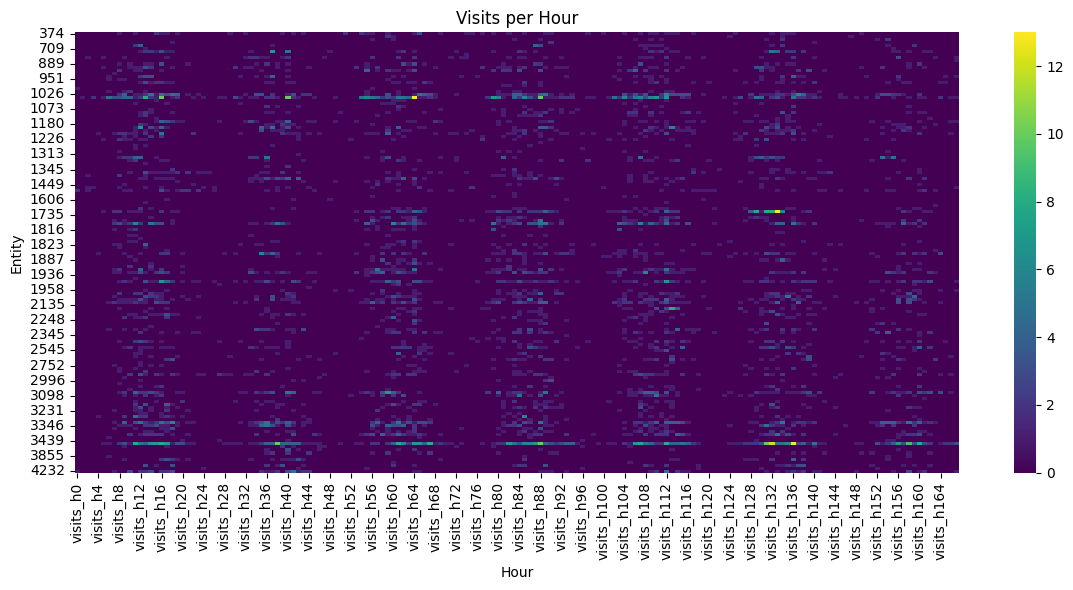

In [5]:
# Extract just the nonmissing visits data
visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()


In [6]:
tr = df.dropna(subset=visits_cols)    #training set

tr = tr.melt(
  id_vars=['prim_occ', 'sqmeters', 'build_id'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)
tr['hour_of_week'] = tr['hour_of_week'].str.extract(r'(\d+)').astype(int)
tr['sqmeters'] = pd.to_numeric(tr['sqmeters'], errors='coerce')
tr['hour_d'] = tr['hour_of_week'] % 24 # 0-23
tr['sin_hod'] = np.sin(2*np.pi*tr['hour_d']/24)
tr['cos_hod'] = np.cos(2*np.pi*tr['hour_d']/24)


tr['day_w'] = tr['hour_of_week'] // 24 # 0-6
tr['sin_dow'] = np.sin(2*np.pi*tr['day_w']/7)
tr['cos_dow'] = np.cos(2*np.pi*tr['day_w']/7)


tr['sqmeters_scaled'] = tr['sqmeters'] / tr['sqmeters'].max()

tr['sq_q'] = pd.qcut(tr['sqmeters_scaled'], 4, labels=False)

# tr['x_day'] = tr['day'].cat.codes
tr['x_prim_occ'] = tr['prim_occ'].astype('category').cat.codes



In [7]:
x_sin_hod = torch.tensor(tr['sin_hod'].values, dtype=torch.float32).unsqueeze(1)
x_cos_hod = torch.tensor(tr['cos_hod'].values, dtype=torch.float32).unsqueeze(1)
x_area = torch.tensor(tr['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1)
x_sin_dow = torch.tensor(tr['sin_dow'].values, dtype=torch.float32).unsqueeze(1)
x_cos_dow = torch.tensor(tr['cos_dow'].values, dtype=torch.float32).unsqueeze(1)
x_type = torch.tensor(tr['x_prim_occ'].values, dtype=torch.long)

device = torch.device('gpu' if torch.cuda.is_available() else 'cpu')
y = torch.tensor(tr['visits'].values, dtype=torch.float32).unsqueeze(1)

x_sin_hod = x_sin_hod.to(device)
x_cos_hod = x_cos_hod.to(device)
x_area = x_area.to(device)
x_sin_dow  = x_sin_dow.to(device)
x_cos_dow = x_cos_dow.to(device)
y      = y.to(device)

In [8]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        input_size = 5 + 5
        hidden_size = 32
        output_size = 1
        
        self.type_emb = nn.Embedding(13, 5)
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Softplus()  
        )

    def forward(self, x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type):
        x_type_emb = self.type_emb(x_type)
        x = torch.cat([x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type_emb], dim=1)
        return self.net(x)

In [9]:
loss_fn = nn.PoissonNLLLoss(log_input=False)

In [10]:
model = Net().to(device)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    loss = loss_fn(model(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type), y)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 0.8325
Epoch 50: loss = 0.6032
Epoch 100: loss = 0.4668
Epoch 150: loss = 0.4305
Epoch 200: loss = 0.4191
Epoch 250: loss = 0.4092
Epoch 300: loss = 0.3961
Epoch 350: loss = 0.3807
Epoch 400: loss = 0.3759
Epoch 450: loss = 0.3740
Epoch 500: loss = 0.3724
Epoch 550: loss = 0.3708
Epoch 600: loss = 0.3693
Epoch 650: loss = 0.3678
Epoch 700: loss = 0.3660
Epoch 750: loss = 0.3641
Epoch 800: loss = 0.3624
Epoch 850: loss = 0.3610
Epoch 900: loss = 0.3597
Epoch 950: loss = 0.3583


In [13]:
model.eval()
with torch.no_grad():
    pred = (model(x_sin_hod, x_cos_hod, x_area, x_sin_dow, x_cos_dow, x_type)
            .detach()
            .cpu()
            .squeeze()
            .numpy())
    obs = y.detach().cpu().squeeze().numpy()

df_pred = pd.DataFrame({
    'build_id': tr['build_id'],
    'type':    tr['prim_occ'],
    'day_w':     tr['day_w'],        
    'hour_d':    tr['hour_d'],           
    'sq_q':    tr['sq_q'],
    'pred':    pred,
    'obs':     obs
})

df_grp = (
    df_pred
    .groupby(['type', 'day_w','hour_d'], observed=True)[['pred','obs']]
    .mean()
    .reset_index()
)


known_categories = set(tr['prim_occ'].unique())

In [20]:
np.random.seed = 42
df_pred['hour_w'] = df_pred['day_w'] * 24 + df_pred['hour_d']
df_pred['simulated'] = np.random.poisson(df_pred['pred'])
pred_wide = df_pred.pivot(index = 'build_id', columns = 'hour_w', values = 'simulated')
pred_wide

hour_w,0,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,167
build_id,,,,,,,,,,,,,,,,,,,,,
1301049,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1302967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1302984,0,0,0,0,0,0,0,0,1,1,...,0,0,1,0,0,0,1,0,0,0
1303044,0,0,1,0,0,0,0,0,1,2,...,0,1,0,0,0,0,0,1,0,0
1303122,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313687,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1313691,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1314080,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


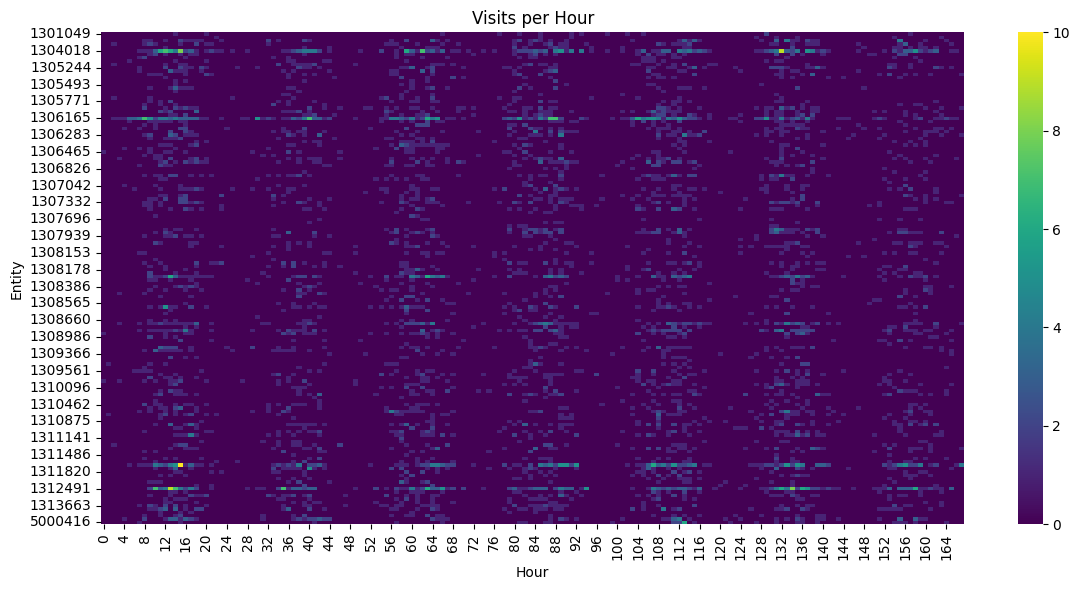

In [21]:
# # Extract just the nonmissing visits data
# visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()

In [13]:
nonres = df[df['occ_cls']!= 'Residential'][pd.isna(df['sg_match'])]

nonres = nonres.melt(
  id_vars=['prim_occ', 'sqmeters', 'build_id'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)

nonres['prim_occ'] = nonres['prim_occ'].where(
    nonres['prim_occ'].isin(known_categories),
    'Unclassified'
)

nonres['hour_of_week'] = nonres['hour_of_week'].str.extract(r'(\d+)').astype(int)
nonres['sqmeters'] = pd.to_numeric(nonres['sqmeters'], errors='coerce')
nonres['hour_d'] = nonres['hour_of_week'] % 24 # 0-23
nonres['sin_hod'] = np.sin(2*np.pi*nonres['hour_d']/24)
nonres['cos_hod'] = np.cos(2*np.pi*nonres['hour_d']/24)


nonres['day_w'] = nonres['hour_of_week'] // 24 # 0-6
nonres['sin_dow'] = np.sin(2*np.pi*nonres['day_w']/7)
nonres['cos_dow'] = np.cos(2*np.pi*nonres['day_w']/7)
nonres['sqmeters_scaled'] = nonres['sqmeters'] / nonres['sqmeters'].max()

nonres['x_prim_occ'] = nonres['prim_occ'].astype('category').cat.codes
nonres

C:\Users\ngoc0\AppData\Local\Temp\ipykernel_16564\1271850532.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nonres = df[df['occ_cls']!= 'Residential'][pd.isna(df['sg_match'])]


,prim_occ,sqmeters,build_id,hour_of_week,visits,hour_d,sin_hod,cos_hod,day_w,sin_dow,cos_dow,sqmeters_scaled,x_prim_occ
0,Unclassified,216.731110,1299962,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.040092,12
1,General Services,1100.336500,1300561,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.203543,2
2,General Services,194.563080,1300567,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.035991,2
3,General Services,214.265960,1300598,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.039636,2
4,Unclassified,324.549620,1299480,0,NaN,0,0.000000,1.000000,0,0.000000,1.00000,0.060036,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116755,Unclassified,197.486420,1315314,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.036532,12
116756,Unclassified,51.079002,1315387,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.009449,12
116757,Personal and Repair Services,464.080100,1315389,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.085847,6
116758,Unclassified,188.199250,1315396,167,NaN,23,-0.258819,0.965926,6,-0.781831,0.62349,0.034814,12


In [14]:
z_sin_hod = torch.tensor(nonres['sin_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_cos_hod = torch.tensor(nonres['cos_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_area = torch.tensor(nonres['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_sin_dow = torch.tensor(nonres['sin_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_cos_dow = torch.tensor(nonres['cos_dow'].values, dtype=torch.float32).unsqueeze(1).to(device)
z_type = torch.tensor(nonres['x_prim_occ'].values, dtype=torch.long).to(device)


In [20]:
fill = model(z_sin_hod, z_cos_hod, z_area, z_sin_dow, z_cos_dow, z_type).detach().cpu().squeeze().numpy()
df_pred = pd.DataFrame({
    'build_id': nonres['build_id'],
    'type':    nonres['prim_occ'],
    'day_w':     nonres['day_w'],        
    'hour_d':    nonres['hour_d'],           
    'pred':    fill
})

df_pred['hour_w'] = df_pred['day_w'] * 24 + df_pred['hour_d']
pred_wide = df_pred.pivot(index = 'build_id', columns = 'hour_w', values = 'pred')

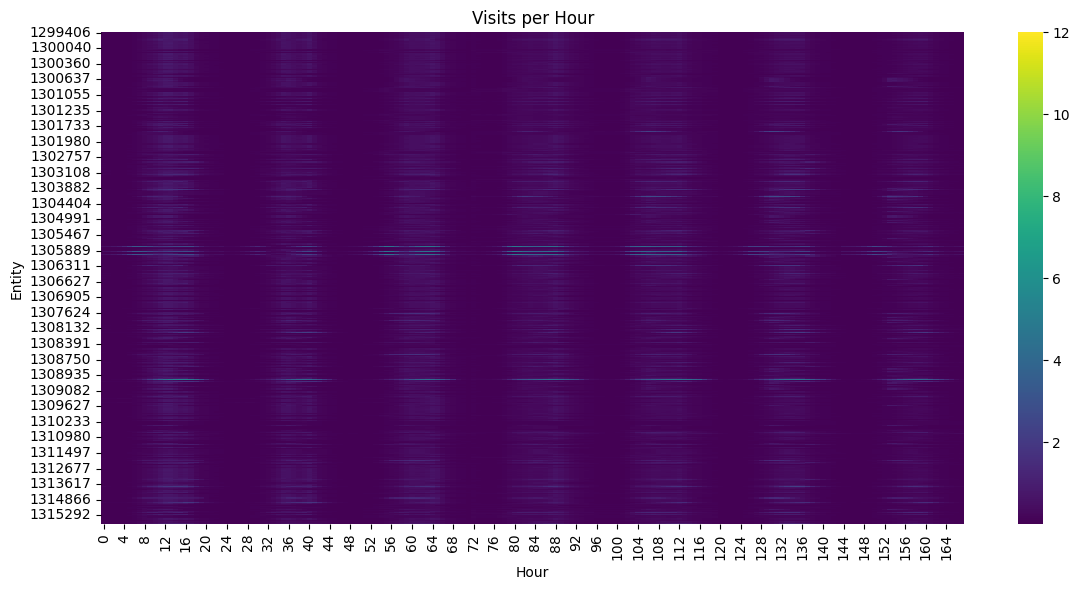

In [21]:
# # Extract just the nonmissing visits data
# visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(pred_wide, cmap='viridis', cbar=True, vmax = 12)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()

KeyError: 'day'

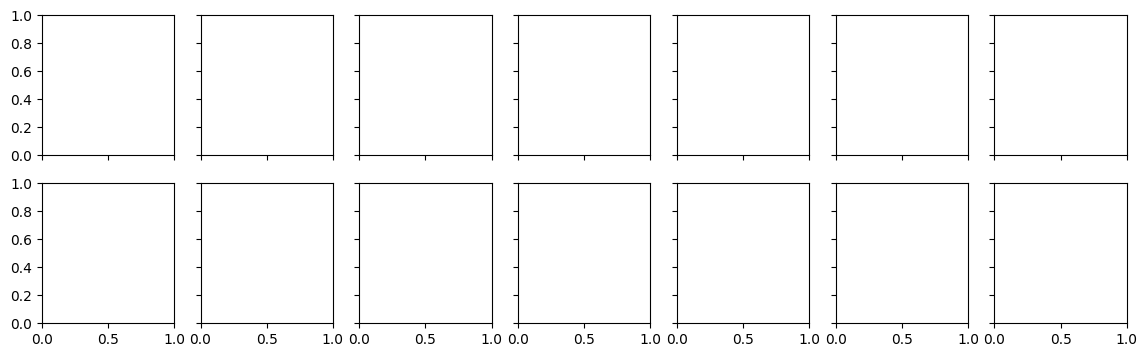

In [16]:
# Parameters
quartiles = [0, 3]  # Q1 and Q4
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(2, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (
            (df_pred['day'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'], marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(day, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Save the model weights
torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
# Demo of loading model
# note need the Net() class definition to load the model
model_loaded = Net()
model_loaded.load_state_dict(torch.load('model_weights.pth', map_location='cpu'))
model_loaded.eval() 

with torch.no_grad():
    sample_preds = model_loaded(x_hour, x_area, x_day, x_type)

print("Sample predictions:", sample_preds[:5])

NameError: name 'Net' is not defined